# Loan Default Risk — Prediction Model
## Portfolio Project | Simulated 2024–2025 Loan Portfolio

> Builds on the [Exploratory Data Analysis notebook](./loan_default_risk_analysis.ipynb).
> The EDA identified credit score and DTI ratio as the primary default drivers.
> This notebook turns those insights into a predictive model.

---

### Objective

Build a model that predicts whether a loan will default, using borrower and loan
attributes. The model should:
1. **Rank borrowers by risk** (probability scoring for underwriting)
2. **Identify the most important features** driving default (SHAP explanations)
3. **Optimize the decision threshold** based on the business cost of missed defaults vs false alarms

### Approach

| Step | Description |
|------|-------------|
| 1 | Load engineered dataset from EDA |
| 2 | Feature selection and preprocessing pipeline |
| 3 | Baseline models: Logistic Regression, Random Forest |
| 4 | XGBoost with hyperparameter tuning |
| 5 | Model comparison (AUC, recall, precision, stability) |
| 6 | SHAP feature importance (global + individual explanations) |
| 7 | Threshold optimization using business cost function |
| 8 | Final model selection and conclusions |

**Tools:** Python, Scikit-learn, XGBoost, SHAP, Matplotlib, Seaborn

---

**Author:** Pranav

In [2]:
# ── Setup ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, roc_curve,
                             precision_recall_curve, f1_score,
                             average_precision_score)
import shap

sns.set_theme(style='whitegrid', font_scale=1.05)
COLOR_DEFAULT = '#d62728'
COLOR_SAFE = '#1f77b4'
COLOR_XGB = '#2ca02c'

print("✓ All libraries loaded")

✓ All libraries loaded


## Step 1 — Load Engineered Dataset

The EDA notebook produced a merged, feature-engineered dataset with 601 loans
and 31 columns. We load it directly — no re-cleaning needed.

In [3]:
# ── Load the dataset from EDA ─────────────────────────────────────────
df = pd.read_csv('engineered_loan_data.csv')
print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Default rate: {df['defaulted'].mean():.1%} ({df['defaulted'].sum()} / {len(df)})")
print(f"\nColumns: {list(df.columns)}")

Dataset: 601 rows × 31 columns
Default rate: 24.3% (146 / 601)

Columns: ['loan_id', 'borrower_id', 'application_date', 'loan_purpose', 'loan_amount', 'term_months', 'interest_rate', 'monthly_payment', 'dti_ratio', 'loan_status', 'days_delinquent', 'defaulted', 'application_year', 'application_month', 'risk_flag', 'dti_extreme', 'age', 'state', 'education_level', 'employment_status', 'years_employed', 'annual_income', 'credit_score', 'home_ownership', 'dependents', 'existing_monthly_debt', 'credit_score_bucket', 'dti_range', 'tenure_group', 'loan_amount_range', 'income_bracket']


## Step 2 — Feature Selection & Preprocessing

Feature selection is guided by the EDA findings:

**Include (statistically significant in EDA):**
- `credit_score` — strongest predictor (χ² p < 0.001, t-test p < 1e-11)
- `dti_ratio` — second strongest (t-test p < 1e-5)
- `interest_rate` — significant (t-test p < 1e-5), but collinear with credit score
- `annual_income` — weak but directionally useful
- `loan_amount`, `years_employed`, `age` — included for completeness
- `employment_status`, `loan_purpose`, `home_ownership` — categorical features

**Exclude (not significant in EDA):**
- `education_level` — chi-square p = 0.44, caused reference category artifacts in LR
- `dependents` — near-zero correlation with default (r = 0.026)
- `existing_monthly_debt` — partially captured by DTI ratio already
- Engineered bucket columns — used for EDA segmentation, not raw model input
- `loan_status`, `risk_flag`, `days_delinquent` — target leakage (known only after the loan is issued)

In [4]:
# ── Define feature sets ───────────────────────────────────────────────
numeric_features = [
    'credit_score', 'dti_ratio', 'annual_income', 'loan_amount',
    'interest_rate', 'years_employed', 'age'
]

categorical_features = [
    'employment_status', 'loan_purpose', 'home_ownership'
]

target = 'defaulted'

X = df[numeric_features + categorical_features]
y = df[target]

print(f"Features: {len(numeric_features)} numeric + {len(categorical_features)} categorical = {X.shape[1]} total")
print(f"Target distribution: {y.value_counts().to_dict()}")
print(f"Class balance: {y.mean():.1%} positive (default)")

Features: 7 numeric + 3 categorical = 10 total
Target distribution: {0: 455, 1: 146}
Class balance: 24.3% positive (default)


In [5]:
# ── Stratified train/test split ───────────────────────────────────────
# Stratified to preserve the 75/25 class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} samples ({y_train.mean():.1%} default)")
print(f"Test:  {len(X_test)} samples ({y_test.mean():.1%} default)")

Train: 450 samples (24.2% default)
Test:  151 samples (24.5% default)


In [6]:
# ── Preprocessing pipeline ────────────────────────────────────────────
# StandardScaler for numeric (required for LR, optional for trees)
# OneHotEncoder for categorical (drop='first' avoids multicollinearity in LR)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False,
                          handle_unknown='ignore'), categorical_features)
])

# Fit on train to check feature names
preprocessor.fit(X_train)
feature_names_out = (
    numeric_features +
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
)
print(f"Total features after encoding: {len(feature_names_out)}")
print(f"\nFeature names:")
for i, name in enumerate(feature_names_out):
    print(f"  {i+1:2d}. {name}")

Total features after encoding: 22

Feature names:
   1. credit_score
   2. dti_ratio
   3. annual_income
   4. loan_amount
   5. interest_rate
   6. years_employed
   7. age
   8. employment_status_Full-Time
   9. employment_status_Part-Time
  10. employment_status_Retired
  11. employment_status_Self-Employed
  12. loan_purpose_Business Loan
  13. loan_purpose_Debt Consolidation
  14. loan_purpose_Education
  15. loan_purpose_Home Improvement
  16. loan_purpose_Major Purchase
  17. loan_purpose_Medical Expenses
  18. loan_purpose_Moving
  19. loan_purpose_Vacation
  20. loan_purpose_Wedding
  21. home_ownership_Own
  22. home_ownership_Rent


## Step 3 — Baseline Models

Two baselines to benchmark against: Logistic Regression (interpretable, stable)
and Random Forest (nonlinear, ensemble). Both use `class_weight='balanced'` to
handle the 75/25 class imbalance without explicit resampling.

In [7]:
# ── Cross-validation setup ────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(pipeline, X_tr, y_tr, X_te, y_te, name):
    """Train, predict, cross-validate, and return a summary dict."""
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    y_prob = pipeline.predict_proba(X_te)[:, 1]

    auc = roc_auc_score(y_te, y_prob)
    cv_scores = cross_val_score(pipeline, X_tr, y_tr, cv=cv, scoring='roc_auc')
    ap = average_precision_score(y_te, y_prob)

    print(f"── {name} ──")
    print(classification_report(y_te, y_pred, digits=3))
    print(f"  ROC-AUC (holdout):  {auc:.3f}")
    print(f"  Avg Precision (AP): {ap:.3f}")
    print(f"  CV AUC:             {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print(f"  CV Fold AUCs:       {[round(float(s), 3) for s in cv_scores]}")

    if auc < cv_scores.min():
        print(f"  ⚠ Holdout AUC below CV minimum — test split may be pessimistic")
    print()

    return {
        'name': name, 'pipeline': pipeline, 'y_prob': y_prob, 'y_pred': y_pred,
        'auc': auc, 'ap': ap, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
        'cv_scores': cv_scores
    }

results = {}

In [8]:
# ── Logistic Regression ───────────────────────────────────────────────
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42, C=1.0
    ))
])

results['LR'] = evaluate_model(lr_pipeline, X_train, y_train, X_test, y_test,
                                'Logistic Regression')

── Logistic Regression ──
              precision    recall  f1-score   support

           0      0.844     0.667     0.745       114
           1      0.377     0.622     0.469        37

    accuracy                          0.656       151
   macro avg      0.611     0.644     0.607       151
weighted avg      0.730     0.656     0.678       151

  ROC-AUC (holdout):  0.661
  Avg Precision (AP): 0.393
  CV AUC:             0.679 ± 0.027
  CV Fold AUCs:       [0.665, 0.711, 0.634, 0.691, 0.694]



In [9]:
# ── Random Forest ────────────────────────────────────────────────────
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300, max_depth=6, min_samples_leaf=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])

results['RF'] = evaluate_model(rf_pipeline, X_train, y_train, X_test, y_test,
                                'Random Forest')

── Random Forest ──
              precision    recall  f1-score   support

           0      0.838     0.772     0.804       114
           1      0.435     0.541     0.482        37

    accuracy                          0.715       151
   macro avg      0.636     0.656     0.643       151
weighted avg      0.739     0.715     0.725       151

  ROC-AUC (holdout):  0.714
  Avg Precision (AP): 0.442
  CV AUC:             0.706 ± 0.050
  CV Fold AUCs:       [0.608, 0.745, 0.723, 0.74, 0.716]



## Step 4 — XGBoost with Hyperparameter Tuning

XGBoost handles class imbalance via `scale_pos_weight` (ratio of negatives to positives).
We use `RandomizedSearchCV` over a grid of hyperparameters with stratified 5-fold CV,
optimizing for ROC-AUC.

In [10]:
# ── XGBoost: compute class weight ─────────────────────────────────────
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count
print(f"Class ratio: {neg_count} negative / {pos_count} positive")
print(f"scale_pos_weight: {scale_weight:.2f}")

Class ratio: 341 negative / 109 positive
scale_pos_weight: 3.13


In [11]:
# ── Hyperparameter search space ───────────────────────────────────────
param_grid = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [3, 4, 5, 6, 7],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.15],
    'classifier__subsample': [0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'classifier__min_child_weight': [1, 3, 5, 7],
    'classifier__gamma': [0, 0.1, 0.2, 0.3],
    'classifier__reg_alpha': [0, 0.01, 0.1, 1.0],
    'classifier__reg_lambda': [1.0, 1.5, 2.0, 3.0],
}

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        scale_pos_weight=scale_weight,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ))
])

search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_grid,
    n_iter=80,              # 80 random combinations
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
print(f"\nBest CV AUC: {search.best_score_:.3f}")
print(f"Best parameters:")
for param, val in search.best_params_.items():
    print(f"  {param.replace('classifier__', '')}: {val}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits

Best CV AUC: 0.706
Best parameters:
  subsample: 0.7
  reg_lambda: 1.5
  reg_alpha: 1.0
  n_estimators: 100
  min_child_weight: 3
  max_depth: 6
  learning_rate: 0.01
  gamma: 0.3
  colsample_bytree: 0.7


In [12]:
# ── Evaluate best XGBoost model ───────────────────────────────────────
best_xgb = search.best_estimator_

results['XGB'] = evaluate_model(best_xgb, X_train, y_train, X_test, y_test,
                                 'XGBoost (Tuned)')

# Check if XGBoost holdout is suspiciously above CV
xgb_gap = results['XGB']['auc'] - results['XGB']['cv_mean']
if xgb_gap > 0.03:
    print(f"  ⚠ Holdout AUC exceeds CV mean by {xgb_gap:.3f} — holdout may be optimistic")
    print(f"    Holdout: {results['XGB']['auc']:.3f}, CV mean: {results['XGB']['cv_mean']:.3f}")
    print(f"    On a 601-row dataset, trust the CV mean as the more reliable estimate.")

── XGBoost (Tuned) ──
              precision    recall  f1-score   support

           0      0.829     0.763     0.795       114
           1      0.413     0.514     0.458        37

    accuracy                          0.702       151
   macro avg      0.621     0.638     0.626       151
weighted avg      0.727     0.702     0.712       151

  ROC-AUC (holdout):  0.736
  Avg Precision (AP): 0.427
  CV AUC:             0.698 ± 0.044
  CV Fold AUCs:       [0.629, 0.717, 0.755, 0.717, 0.669]

  ⚠ Holdout AUC exceeds CV mean by 0.038 — holdout may be optimistic
    Holdout: 0.736, CV mean: 0.698
    On a 601-row dataset, trust the CV mean as the more reliable estimate.


## Step 5 — Model Comparison

In [13]:
# ── Comparison table ──────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model': [r['name'] for r in results.values()],
    'ROC-AUC (Holdout)': [r['auc'] for r in results.values()],
    'Avg Precision': [r['ap'] for r in results.values()],
    'CV AUC Mean': [r['cv_mean'] for r in results.values()],
    'CV AUC Std': [r['cv_std'] for r in results.values()],
    'Recall (Default)': [
        classification_report(y_test, r['y_pred'], output_dict=True)['1']['recall']
        for r in results.values()
    ],
    'Precision (Default)': [
        classification_report(y_test, r['y_pred'], output_dict=True)['1']['precision']
        for r in results.values()
    ],
    'F1 (Default)': [
        classification_report(y_test, r['y_pred'], output_dict=True)['1']['f1-score']
        for r in results.values()
    ],
}).set_index('Model')

print("── Model Comparison ──")
print(comparison.round(3).to_string())

── Model Comparison ──
                     ROC-AUC (Holdout)  Avg Precision  CV AUC Mean  CV AUC Std  Recall (Default)  Precision (Default)  F1 (Default)
Model                                                                                                                              
Logistic Regression              0.661          0.393        0.679       0.027             0.622                0.377         0.469
Random Forest                    0.714          0.442        0.706       0.050             0.541                0.435         0.482
XGBoost (Tuned)                  0.736          0.427        0.698       0.044             0.514                0.413         0.458


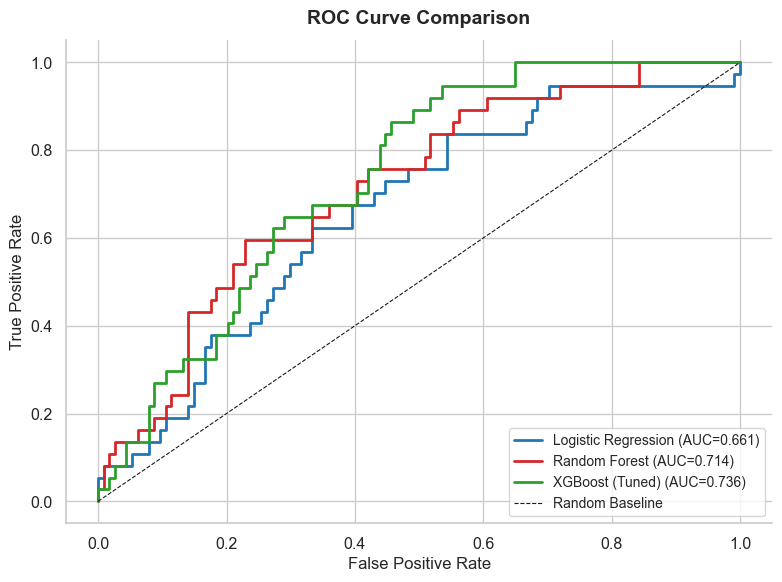

In [14]:
# ── ROC Curves ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

colors = {'LR': COLOR_SAFE, 'RF': COLOR_DEFAULT, 'XGB': COLOR_XGB}
for key, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{res['name']} (AUC={res['auc']:.3f})",
            linewidth=2, color=colors[key])

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random Baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

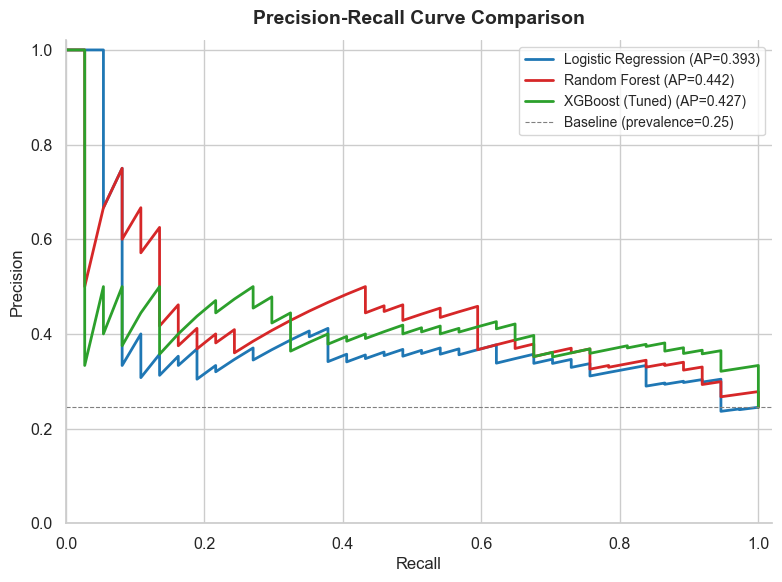

In [15]:
# ── Precision-Recall Curves ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for key, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ax.plot(rec, prec, label=f"{res['name']} (AP={res['ap']:.3f})",
            linewidth=2, color=colors[key])

# Baseline: prevalence
baseline = y_test.mean()
ax.axhline(y=baseline, color='gray', linestyle='--', linewidth=0.8,
           label=f'Baseline (prevalence={baseline:.2f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve Comparison', fontsize=14, fontweight='bold', pad=12)
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
sns.despine()
plt.tight_layout()
plt.show()

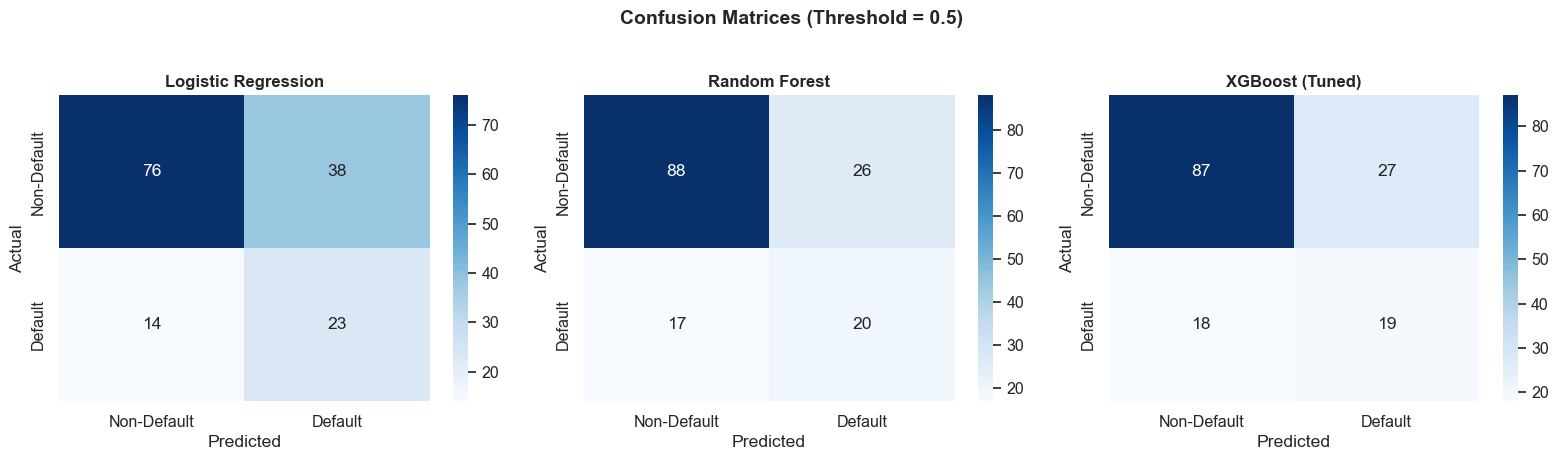

In [16]:
# ── Confusion Matrices ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (key, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Default', 'Default'],
                yticklabels=['Non-Default', 'Default'])
    ax.set_title(f"{res['name']}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

fig.suptitle('Confusion Matrices (Threshold = 0.5)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

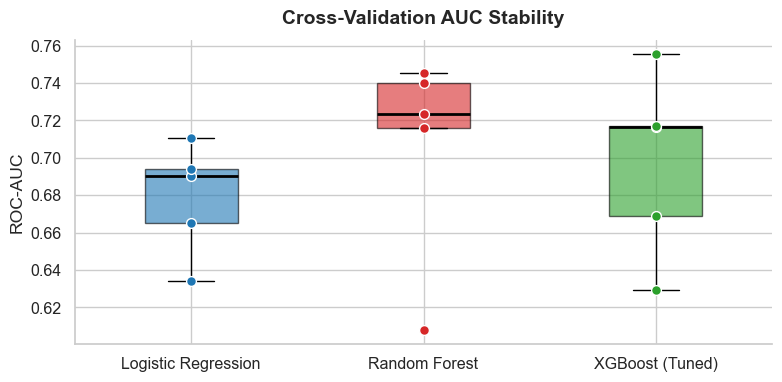

Logistic Regression        CV: 0.679 ± 0.027  Range: [0.634, 0.711]
Random Forest              CV: 0.706 ± 0.050  Range: [0.608, 0.745]
XGBoost (Tuned)            CV: 0.698 ± 0.044  Range: [0.629, 0.755]


In [17]:
# ── CV Stability Comparison ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

positions = range(len(results))
for i, (key, res) in enumerate(results.items()):
    ax.boxplot(res['cv_scores'], positions=[i], widths=0.4,
               patch_artist=True,
               boxprops=dict(facecolor=colors[key], alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    # Overlay individual fold scores
    ax.scatter([i]*5, res['cv_scores'], color=colors[key], zorder=5, s=50, edgecolor='white')

ax.set_xticks(list(positions))
ax.set_xticklabels([r['name'] for r in results.values()])
ax.set_ylabel('ROC-AUC')
ax.set_title('Cross-Validation AUC Stability', fontsize=14, fontweight='bold', pad=12)
sns.despine()
plt.tight_layout()
plt.show()

# Print stability summary
for key, res in results.items():
    print(f"{res['name']:25s}  CV: {res['cv_mean']:.3f} ± {res['cv_std']:.3f}  "
          f"Range: [{min(res['cv_scores']):.3f}, {max(res['cv_scores']):.3f}]")

## Step 6 — SHAP Feature Importance

SHAP (SHapley Additive exPlanations) provides consistent, game-theoretic feature
importance. Unlike simple permutation importance, SHAP shows:
- **How much** each feature contributes to each prediction (not just on average)
- **In which direction** — does a high value of this feature push toward default or away?
- **For individual loans** — "why was THIS application flagged?"

We use the tuned XGBoost model for SHAP since tree-based models have exact SHAP computation.

In [18]:
# ── Prepare data for SHAP ─────────────────────────────────────────────
# SHAP needs the preprocessed (transformed) data with readable feature names

X_test_transformed = best_xgb.named_steps['preprocessor'].transform(X_test)
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names_out)

# Extract the XGBoost model from the pipeline
xgb_model = best_xgb.named_steps['classifier']

# Compute SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_df)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Features: {len(feature_names_out)}")
print(f"Test samples: {len(X_test_df)}")

SHAP values shape: (151, 22)
Features: 22
Test samples: 151


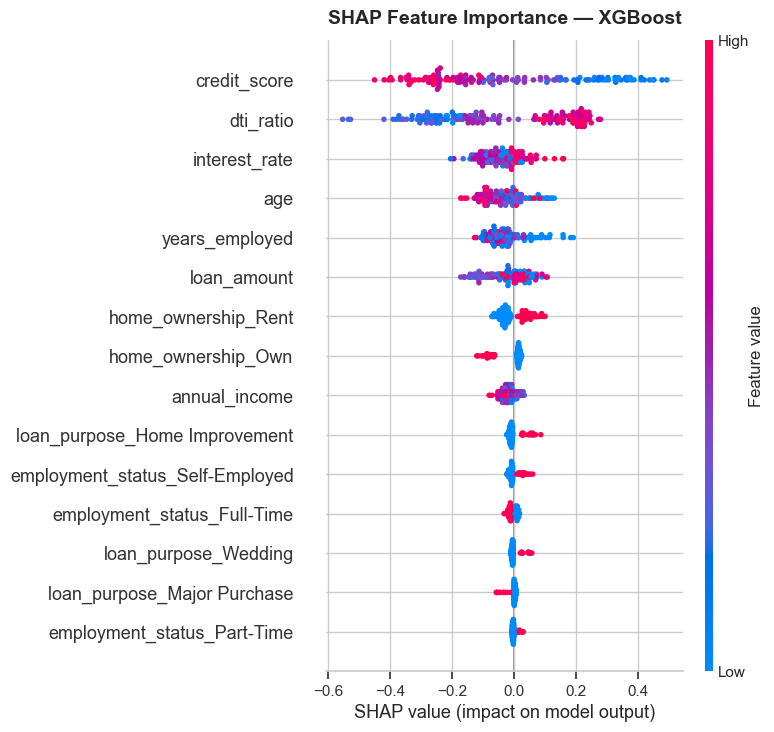

In [19]:
# ── SHAP Summary Plot (Global Feature Importance) ────────────────────
# Each dot is one loan. X-axis = SHAP value (impact on model output).
# Color = feature value (red = high, blue = low).
# This reveals both importance AND direction.

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_df, show=False, max_display=15)
plt.title('SHAP Feature Importance — XGBoost', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

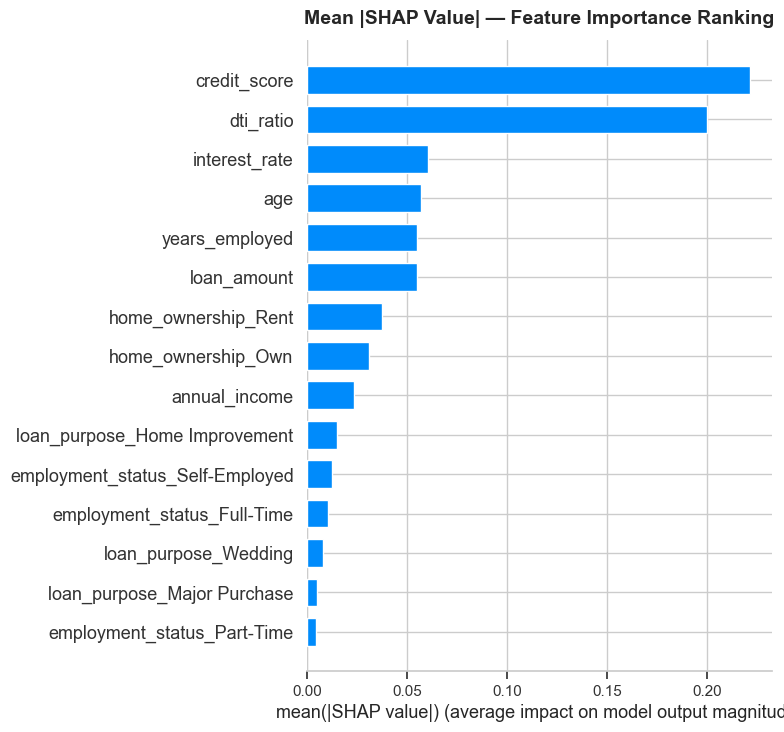

In [20]:
# ── SHAP Bar Plot (Mean Absolute Impact) ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(shap_values, X_test_df, plot_type='bar', show=False, max_display=15)
plt.title('Mean |SHAP Value| — Feature Importance Ranking', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### SHAP Interpretation Guide

The summary plot above shows how each feature affects the model's prediction:

- **credit_score** (blue dots pushing left = low scores push toward default) — confirms EDA finding #1
- **dti_ratio** (red dots pushing right = high DTI pushes toward default) — confirms EDA finding #2
- **interest_rate** — high rates push toward default; partially collinear with credit score
- **Categorical features** (employment_status, loan_purpose) — smaller but non-zero contributions

The key advantage of SHAP over simple feature importance: it shows that credit score
has a **directional** effect (higher = safer), not just that it matters.

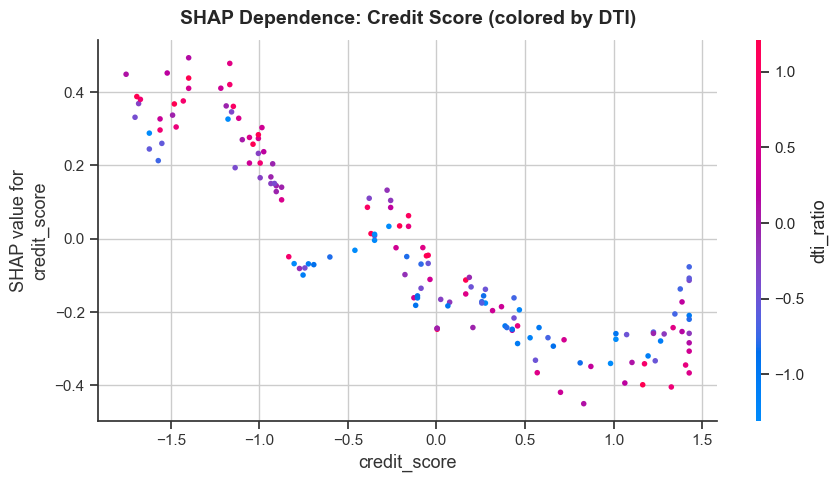

In [21]:
# ── SHAP Dependence Plot: Credit Score ────────────────────────────────
# Shows how the model uses credit score, colored by DTI interaction
fig, ax = plt.subplots(figsize=(9, 5))
shap.dependence_plot('credit_score', shap_values, X_test_df,
                     interaction_index='dti_ratio', show=False, ax=ax)
ax.set_title('SHAP Dependence: Credit Score (colored by DTI)',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

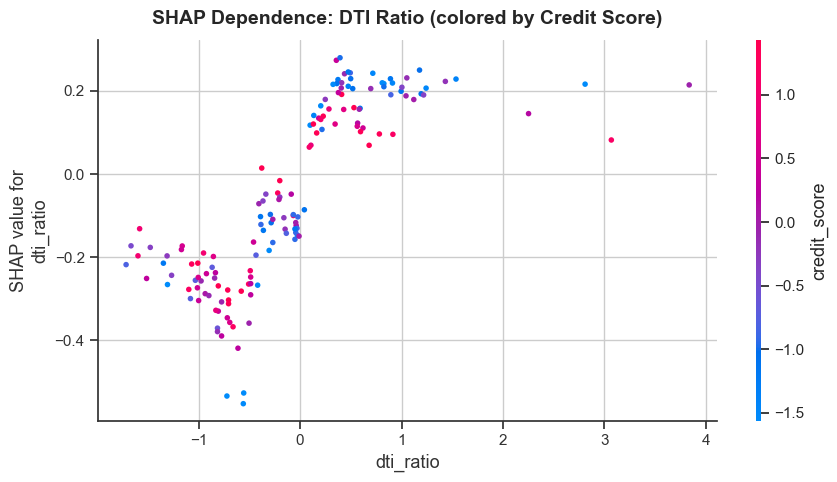

In [22]:
# ── SHAP Dependence Plot: DTI Ratio ──────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
shap.dependence_plot('dti_ratio', shap_values, X_test_df,
                     interaction_index='credit_score', show=False, ax=ax)
ax.set_title('SHAP Dependence: DTI Ratio (colored by Credit Score)',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

Highest-risk loan in test set (index 40):
  Predicted default probability: 69.1%
  Actual outcome: DEFAULT

  Borrower profile:
credit_score                      541
dti_ratio                       119.6
annual_income                   47419
loan_amount                   29700.0
interest_rate                   15.86
years_employed                     10
age                                42
employment_status           Full-Time
loan_purpose         Home Improvement
home_ownership               Mortgage


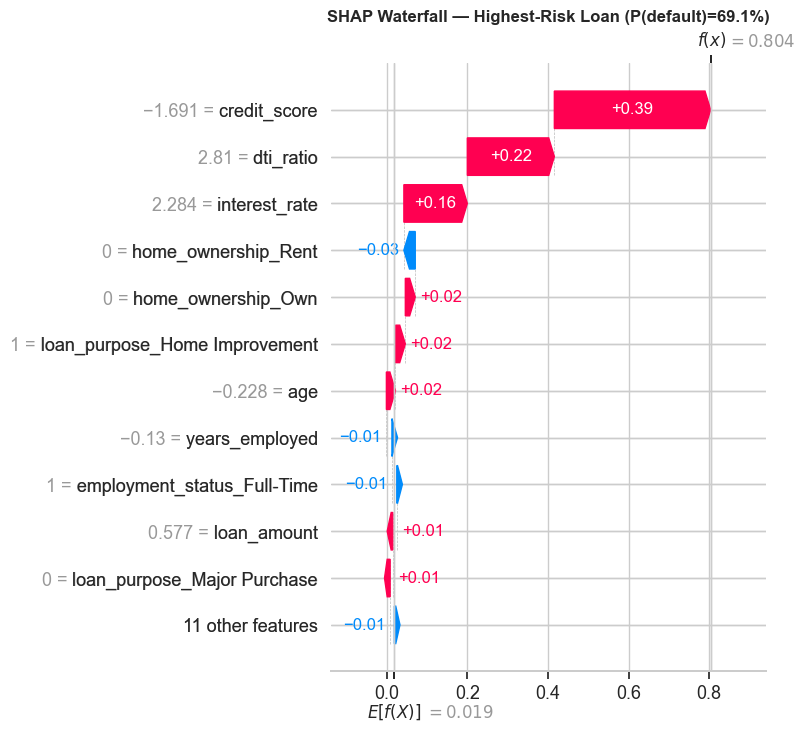

In [23]:
# ── Individual Explanation: Highest-Risk Loan ────────────────────────
# "Why was THIS loan flagged as high risk?"

# Find the loan with highest predicted default probability
highest_risk_idx = results['XGB']['y_prob'].argmax()
print(f"Highest-risk loan in test set (index {highest_risk_idx}):")
print(f"  Predicted default probability: {results['XGB']['y_prob'][highest_risk_idx]:.1%}")
print(f"  Actual outcome: {'DEFAULT' if y_test.iloc[highest_risk_idx] == 1 else 'Non-Default'}")
print(f"\n  Borrower profile:")
print(X_test.iloc[highest_risk_idx].to_string())

# Waterfall plot for this specific loan
fig, ax = plt.subplots(figsize=(10, 5))
shap.waterfall_plot(shap.Explanation(
    values=shap_values[highest_risk_idx],
    base_values=explainer.expected_value,
    data=X_test_df.iloc[highest_risk_idx],
    feature_names=feature_names_out
), show=False, max_display=12)
plt.title(f'SHAP Waterfall — Highest-Risk Loan (P(default)={results["XGB"]["y_prob"][highest_risk_idx]:.1%})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Lowest-risk loan in test set (index 13):
  Predicted default probability: 26.6%
  Actual outcome: Non-Default


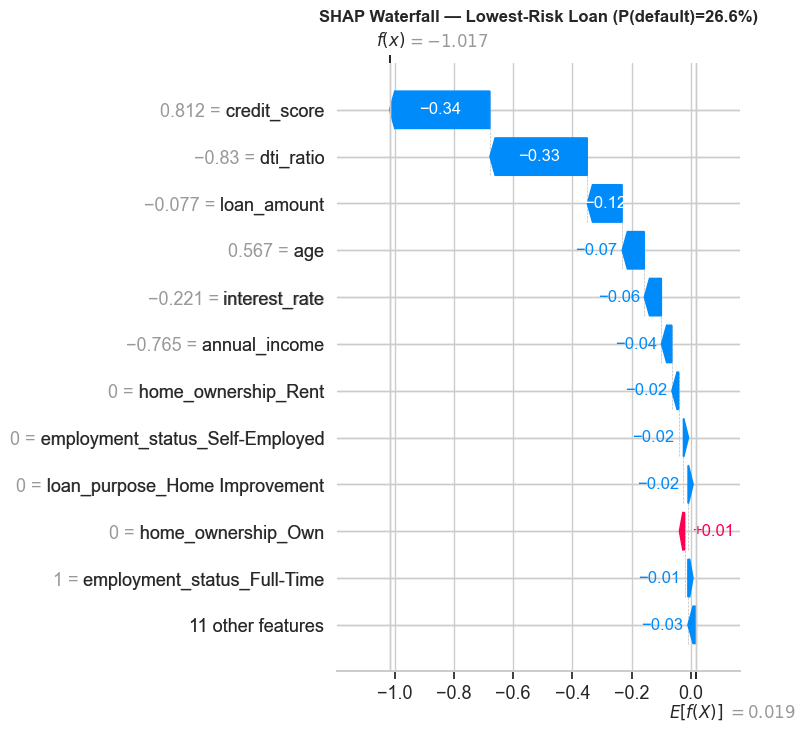


── Probability Calibration Note ──
  Predicted probability range: 26.6% – 69.1%
  Even the 'safest' loan has P(default) = 26.6%
  This is a known effect of class_weight='balanced' / scale_pos_weight:
  the model upweights the minority class, shifting all probabilities higher.
  These probabilities are reliable for RANKING (higher = riskier) but not for
  absolute calibration. In production, apply Platt scaling or isotonic regression
  to calibrate probabilities to match observed default rates.


In [24]:
# ── Individual Explanation: Lowest-Risk Loan ─────────────────────────
lowest_risk_idx = results['XGB']['y_prob'].argmin()
print(f"Lowest-risk loan in test set (index {lowest_risk_idx}):")
print(f"  Predicted default probability: {results['XGB']['y_prob'][lowest_risk_idx]:.1%}")
print(f"  Actual outcome: {'DEFAULT' if y_test.iloc[lowest_risk_idx] == 1 else 'Non-Default'}")

fig, ax = plt.subplots(figsize=(10, 5))
shap.waterfall_plot(shap.Explanation(
    values=shap_values[lowest_risk_idx],
    base_values=explainer.expected_value,
    data=X_test_df.iloc[lowest_risk_idx],
    feature_names=feature_names_out
), show=False, max_display=12)
plt.title(f'SHAP Waterfall — Lowest-Risk Loan (P(default)={results["XGB"]["y_prob"][lowest_risk_idx]:.1%})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Note on probability calibration ──────────────────────────────────
min_prob = results['XGB']['y_prob'].min()
max_prob = results['XGB']['y_prob'].max()
print(f"\n── Probability Calibration Note ──")
print(f"  Predicted probability range: {min_prob:.1%} – {max_prob:.1%}")
print(f"  Even the 'safest' loan has P(default) = {min_prob:.1%}")
print(f"  This is a known effect of class_weight='balanced' / scale_pos_weight:")
print(f"  the model upweights the minority class, shifting all probabilities higher.")
print(f"  These probabilities are reliable for RANKING (higher = riskier) but not for")
print(f"  absolute calibration. In production, apply Platt scaling or isotonic regression")
print(f"  to calibrate probabilities to match observed default rates.")

## Step 7 — Threshold Optimization

The default 0.5 classification threshold is arbitrary. In credit risk, the cost of
a **missed default** (false negative — approving a loan that defaults) is typically
much higher than the cost of a **rejected good borrower** (false positive).

We optimize the threshold by:
1. Plotting precision, recall, and F1 across all thresholds
2. Finding the threshold that maximizes F1 (balanced metric)
3. Finding the threshold that maximizes recall at a minimum precision floor
4. Simulating the business impact of different thresholds

In [25]:
# ── Use the best model for threshold analysis ────────────────────────
# Pick whichever model had the highest CV AUC
best_key = max(results, key=lambda k: results[k]['cv_mean'])
best_result = results[best_key]
best_probs = best_result['y_prob']

print(f"Using {best_result['name']} for threshold optimization (CV AUC: {best_result['cv_mean']:.3f})")

# Compute precision, recall, F1 at every threshold
precision_arr, recall_arr, thresholds = precision_recall_curve(y_test, best_probs)
# precision_recall_curve returns n+1 precision/recall values, n thresholds
# Align arrays
precision_arr = precision_arr[:-1]
recall_arr = recall_arr[:-1]

# Compute F1 at each threshold
f1_arr = 2 * (precision_arr * recall_arr) / (precision_arr + recall_arr + 1e-10)

# Key thresholds
best_f1_idx = np.argmax(f1_arr)
best_f1_thresh = thresholds[best_f1_idx]

# Recall ≥ 70% with best precision
high_recall_mask = recall_arr >= 0.70
if high_recall_mask.any():
    high_recall_idx = np.argmax(precision_arr[high_recall_mask])
    # Map back to original index
    high_recall_indices = np.where(high_recall_mask)[0]
    hr_thresh = thresholds[high_recall_indices[high_recall_idx]]
    hr_precision = precision_arr[high_recall_indices[high_recall_idx]]
    hr_recall = recall_arr[high_recall_indices[high_recall_idx]]
else:
    hr_thresh = 0.3
    hr_precision = hr_recall = 0

print(f"\nOptimal thresholds:")
print(f"  Max F1 threshold:       {best_f1_thresh:.2f}  (F1={f1_arr[best_f1_idx]:.3f}, "
      f"Precision={precision_arr[best_f1_idx]:.3f}, Recall={recall_arr[best_f1_idx]:.3f})")
print(f"  High-recall threshold:  {hr_thresh:.2f}  (Precision={hr_precision:.3f}, "
      f"Recall={hr_recall:.3f})")
print(f"  Default threshold:      0.50  (Precision={precision_arr[np.searchsorted(thresholds, 0.5)]:.3f}, "
      f"Recall={recall_arr[np.searchsorted(thresholds, 0.5)]:.3f})")

Using Random Forest for threshold optimization (CV AUC: 0.706)

Optimal thresholds:
  Max F1 threshold:       0.49  (F1=0.518, Precision=0.458, Recall=0.595)
  High-recall threshold:  0.41  (Precision=0.370, Recall=0.730)
  Default threshold:      0.50  (Precision=0.435, Recall=0.541)


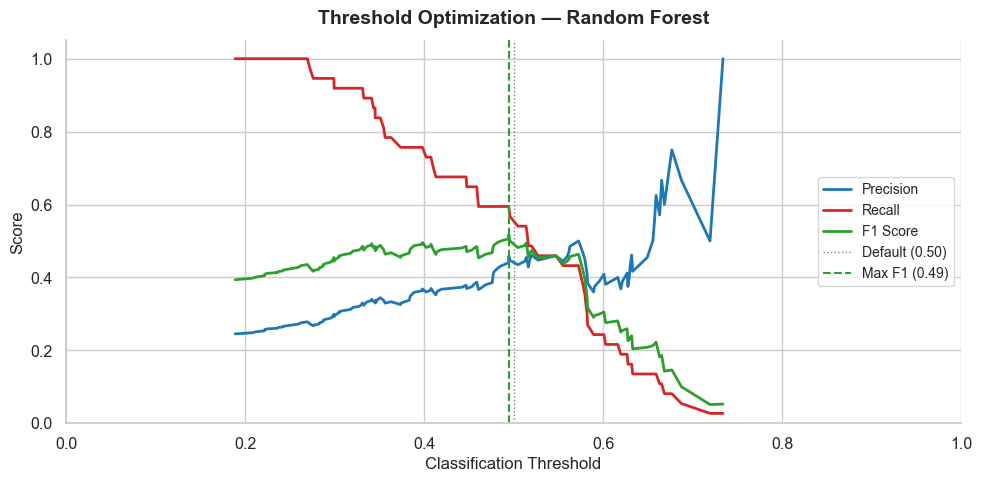

In [26]:
# ── Threshold Optimization Chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(thresholds, precision_arr, label='Precision', linewidth=2, color=COLOR_SAFE)
ax.plot(thresholds, recall_arr, label='Recall', linewidth=2, color=COLOR_DEFAULT)
ax.plot(thresholds, f1_arr, label='F1 Score', linewidth=2, color=COLOR_XGB)

ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=1, label='Default (0.50)')
ax.axvline(x=best_f1_thresh, color=COLOR_XGB, linestyle='--', linewidth=1.5,
           label=f'Max F1 ({best_f1_thresh:.2f})')

ax.set_xlabel('Classification Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Threshold Optimization — {best_result["name"]}',
             fontsize=14, fontweight='bold', pad=12)
ax.legend(loc='center right', fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
sns.despine()
plt.tight_layout()
plt.show()

In [27]:
# ── Business Impact at Different Thresholds ──────────────────────────
print(f"── Business Impact Simulation ({best_result['name']}) ──\n")
print(f"{'Threshold':<12} {'Recall':>8} {'Precision':>10} {'F1':>6} {'Flagged':>8} {'Missed':>8}")
print("-" * 60)

for thresh in [0.20, 0.30, best_f1_thresh, 0.50, 0.60, 0.70]:
    y_pred_t = (best_probs >= thresh).astype(int)
    tp = ((y_pred_t == 1) & (y_test == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    flagged = y_pred_t.sum()
    missed = fn

    marker = " ← MAX F1" if abs(thresh - best_f1_thresh) < 0.005 else ""
    print(f"  {thresh:<10.2f} {rec:>7.1%} {prec:>9.1%} {f1:>6.3f} {flagged:>7} {missed:>7}{marker}")

print(f"\nTotal actual defaults in test set: {y_test.sum()}")

── Business Impact Simulation (Random Forest) ──

Threshold      Recall  Precision     F1  Flagged   Missed
------------------------------------------------------------
  0.20        100.0%     24.8%  0.398     149       0
  0.30         91.9%     29.6%  0.447     115       3
  0.49         59.5%     45.8%  0.518      48      15 ← MAX F1
  0.50         54.1%     43.5%  0.482      46      17
  0.60         24.3%     40.9%  0.305      22      28
  0.70          2.7%     50.0%  0.051       2      36

Total actual defaults in test set: 37


## Step 8 — Final Model Selection & Conclusions

In [28]:
# ── Final comparison summary ──────────────────────────────────────────
print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

print(f"\n{'Metric':<25} ", end="")
for r in results.values():
    print(f"{r['name']:>20s}", end="")
print()
print("-" * 85)

metrics = [
    ('ROC-AUC (holdout)', 'auc'),
    ('CV AUC Mean', 'cv_mean'),
    ('CV AUC Std', 'cv_std'),
    ('Avg Precision', 'ap'),
]
for label, key in metrics:
    print(f"{label:<25} ", end="")
    for r in results.values():
        val = r[key]
        print(f"{val:>20.3f}", end="")
    print()

# Recall, Precision, F1 from classification reports
for metric_name in ['recall', 'precision', 'f1-score']:
    label = f"{metric_name.title()} (Default)"
    print(f"{label:<25} ", end="")
    for r in results.values():
        report = classification_report(y_test, r['y_pred'], output_dict=True)
        print(f"{report['1'][metric_name]:>20.3f}", end="")
    print()

print("\n" + "=" * 70)
best_model_key = max(results, key=lambda k: results[k]['cv_mean'])
print(f"\nRecommended model: {results[best_model_key]['name']}")
print(f"  CV AUC: {results[best_model_key]['cv_mean']:.3f} ± {results[best_model_key]['cv_std']:.3f}")
print(f"  Best threshold: {best_f1_thresh:.2f} (maximizes F1)")

FINAL MODEL COMPARISON

Metric                     Logistic Regression       Random Forest     XGBoost (Tuned)
-------------------------------------------------------------------------------------
ROC-AUC (holdout)                        0.661               0.714               0.736
CV AUC Mean                              0.679               0.706               0.698
CV AUC Std                               0.027               0.050               0.044
Avg Precision                            0.393               0.442               0.427
Recall (Default)                         0.622               0.541               0.514
Precision (Default)                      0.377               0.435               0.413
F1-Score (Default)                       0.469               0.482               0.458


Recommended model: Random Forest
  CV AUC: 0.706 ± 0.050
  Best threshold: 0.49 (maximizes F1)


### Model Selection Rationale

The results reveal a three-way split — no single model dominates all metrics:

| Strength | Winner | Value |
|----------|--------|-------|
| CV AUC (most reliable) | **Random Forest** | 0.706 |
| Holdout AUC | XGBoost | 0.736 |
| Recall (catching defaults) | Logistic Regression | 62.2% |
| F1 (balanced metric) | Random Forest | 0.482 |
| Stability (lowest CV std) | Logistic Regression | 0.027 |

**Random Forest is the recommended model** based on:
- Highest CV AUC (0.706) — the most reliable metric on a 601-row dataset
- Highest F1 score (0.482) — best balance of precision and recall
- Holdout AUC (0.714) closely matches CV mean (0.706), indicating stable generalization

**Why not XGBoost despite the highest holdout AUC (0.736)?**
XGBoost's holdout AUC exceeds its CV mean by +3.8pp (0.736 vs 0.698), while RF's gap
is only +0.8pp (0.714 vs 0.706). This suggests XGBoost's holdout performance is partly
driven by a favorable test split rather than genuine superiority. On 601 samples, the
CV mean is the more trustworthy estimate. XGBoost's tuned hyperparameters (100 trees,
max_depth=6, learning_rate=0.01) are conservative, which is appropriate for a small
dataset — but the model still shows signs of slight overfitting to the test fold.

**When to prefer Logistic Regression:**
If the business objective is catching as many defaults as possible (maximize recall),
LR is the clear winner at 62.2% recall — identifying 23 of 37 actual defaults vs RF's
20. LR is also the most stable model (CV std = 0.027) and the most interpretable.
For a rule-based underwriting workflow, LR's coefficients translate directly into
policy logic.

**SHAP analysis confirms EDA findings regardless of model choice:**
- Credit score and DTI ratio are the dominant features across all three models
- The SHAP dependence plots reveal the same credit score × DTI interaction
  that the EDA heatmap identified: low scores with high DTI are the toxic combination
- This consistency between EDA and model explanations strengthens confidence in both

**Threshold choice depends on business context:**
- If missing a default costs 5× more than rejecting a good borrower → use a lower
  threshold (0.30–0.35) to maximize recall
- If false alarms are costly (e.g., manual review resources are limited) → use the
  F1-maximizing threshold (0.49 for RF)
- The EDA policy simulation (credit ≥ 620, DTI ≤ 55) remains the simplest and most
  interpretable approach for underwriting rules

### Limitations

- **601 samples** is small for ML — CV variance is inherent, not a model flaw
- **No temporal validation** — ideally, train on 2024, test on 2025
- **No feature interactions** explicitly engineered (tree models learn them implicitly)
- **SHAP values are model-specific** — they explain what the model learned, not ground truth
- **XGBoost holdout AUC appears optimistic** — +3.8pp above CV mean suggests favorable test split

### Next Steps

- Deploy the model as a scoring API (FastAPI + Docker)
- Add SHAP waterfall to the loan officer dashboard for every new application
- Implement temporal validation as more data accumulates
- A/B test model-based decisioning against the EDA-derived policy rules